假设我们不以全年为测试集,这样我们尽可能利用最近的时间作为验证集,选一个好的种子.将每个月的折线连起来.是否能进行改进?

# 2020逐月回测：前三个月验证选种子，堆叠各100轮

沿用11最后的两阶段Stacking：第一阶段原7变量→股价；第二阶段第一阶段预测＋金铜昨日涨幅、相对5/20期均价涨幅→股价。两阶段均16→32隐藏层、ReLU、Adam学习率0.01、全批量、各100轮；样本内堆叠，不用折外预测。

候选种子随机抽取10个、排除旧实验种子，并在训练前冻结；全年每月使用相同候选，便于比較。下面代码直接保存具体种子，重新运行不会再次抽样。

每个预测月M：训练数据为验证期开始以前的全部历史；验证期为M前连续3个日历月；测试为M当月。例如2020年1月：训练截至2019-09-30，验证2019-10-01至2019-12-31，测试2020-01-01至2020-01-31。2月训练截至2019-10-31，验证2019年11月至2020年1月，测试2月，依次滚动。此前已发生的月份可以进入后续验证/训练，但未来月份不能进入。

只按验证MAPE最低选择种子，精确并列按固定候选顺序。锁定后不加入验证集重训。选择记录先落盘，再评估当月测试。拼接12个月后报告逐记录全年MAPE（等价于按样本数加权的月MAPE）和12个月等权平均MAPE。

对照：把1月验证选中的同一模型全年冻结，在相同2020日期评估，比较逐月更新是否改善。此对照与1月滚动结果必须一致。两种方案同起点、同候选，比较的变化包括每月扩大训练数据与更新验证/选择，并非单独检验某一个因素。

**时间可用性限制**：输入包含同日金铜价格等，因此是逐月更新模型的同日股价样本外回测，不能称为月初已知整个未来月的预测。此前已查看过2020年，属于历史开发实验，不是全新盲测。滚动均价包括当天、窗口按记录计数，未重新修改原Dataset对齐方式。


In [1]:
from pathlib import Path
import os,json,hashlib,random
import numpy as np
import pandas as pd
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display,Image
ROOT=next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'src/pickle/Dataset.pkl').exists()),Path('/Users/admin/数据分析/ZiJin-Mining/ZiJin-Mining-stock-prediction-'))
OUT=Path(os.environ.get('MLP12_OUT',str(ROOT/'results/mlp_monthly_validation_12')));OUT.mkdir(parents=True,exist_ok=True)
SEEDS=[965409, 640934, 550343, 798291, 374583, 42716, 785634, 565766, 385735, 741131]
EXCLUDED_SEEDS=[0, 1, 7, 21, 42, 100, 123, 999, 2024, 2025]
EPOCHS=100;LR=0.01;VALIDATION_MONTHS=3
torch.set_num_threads(1);torch.use_deterministic_algorithms(True)
assert len(set(SEEDS))==10 and not set(SEEDS)&set(EXCLUDED_SEEDS)
dataset=ROOT/'src/pickle/Dataset.pkl';d=pd.read_pickle(dataset)
raw=d['X'].copy();target=d['Y'].copy();assert raw.index.equals(target.index)
assert raw.index.is_unique and raw.index.is_monotonic_increasing
raw=raw.loc[raw.index<'2021-01-01'];BASE=list(raw.columns);assert len(BASE)==7
y=pd.Series(np.asarray(target).reshape(-1),index=target.index,name='Actual').loc[raw.index]
x=raw.copy();RETURNS=[]
for metal,col in [('gold','Gold Futures Price'),('copper','Copper Futures Price')]:
    name=f'{metal}_daily';x[name]=raw[col]/raw[col].shift(1)-1;RETURNS.append(name)
    for k in [5,20]:
        name=f'{metal}_vs_ma{k}';x[name]=raw[col]/raw[col].rolling(k,min_periods=k).mean()-1;RETURNS.append(name)
valid=np.isfinite(x.to_numpy()).all(axis=1)&np.isfinite(y.to_numpy())
x=x.loc[valid];y=y.loc[x.index];assert (y>0).all()
whole=x.index[x.index.year==2020];assert len(whole)==271
config=dict(seeds=SEEDS,excluded_prior_seeds=EXCLUDED_SEEDS,epochs_per_stage=EPOCHS,validation_months=VALIDATION_MONTHS,hidden=[16,32],activation='ReLU',optimizer='Adam',lr=LR,batch='full',base_features=BASE,stage2_features=['base_prediction']+RETURNS,stage2_training='in-sample predictions; base frozen',refit_after_selection=False,target='same-date original price',selection='minimum preceding-three-calendar-month MAPE; ties by candidate order',test_year=2020,dataset_sha256=hashlib.sha256(dataset.read_bytes()).hexdigest(),torch_version=str(torch.__version__))
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
x.join(y).to_csv(OUT/'features_and_target.csv',index_label='Date')
print('Frozen candidate seeds:',SEEDS)


Frozen candidate seeds: [965409, 640934, 550343, 798291, 374583, 42716, 785634, 565766, 385735, 741131]


In [2]:
history=[]
def fit_stage(X,train_idx,seed,stage,month):
    random.seed(seed);np.random.seed(seed);torch.manual_seed(seed)
    sx=StandardScaler().fit(X.loc[train_idx]);sy=StandardScaler().fit(y.loc[train_idx].to_numpy().reshape(-1,1))
    xt=torch.tensor(sx.transform(X.loc[train_idx]),dtype=torch.float32);yt=torch.tensor(sy.transform(y.loc[train_idx].to_numpy().reshape(-1,1)),dtype=torch.float32)
    model=nn.Sequential(nn.Linear(X.shape[1],16),nn.ReLU(),nn.Linear(16,32),nn.ReLU(),nn.Linear(32,1))
    opt=torch.optim.Adam(model.parameters(),lr=LR)
    for epoch in range(1,EPOCHS+1):
        model.train();opt.zero_grad();loss=((model(xt)-yt)**2).mean();assert torch.isfinite(loss)
        loss.backward();opt.step();model.eval()
        with torch.no_grad():z=model(xt).numpy()
        p=sy.inverse_transform(z).ravel();mse=float(np.mean((p-y.loc[train_idx].to_numpy())**2))
        history.append(dict(Month=month,Seed=seed,Stage=stage,Epoch=epoch,Train_MSE=mse,Train_MSE_standardized=mse/float(sy.scale_[0]**2)))
    torch.save(dict(state_dict=model.state_dict(),features=list(X.columns),seed=seed,epochs=EPOCHS,train_start=str(train_idx.min()),train_end=str(train_idx.max()),sx_mean=sx.mean_.tolist(),sx_scale=sx.scale_.tolist(),sy_mean=sy.mean_.tolist(),sy_scale=sy.scale_.tolist()),OUT/f'{month}_{stage}_seed{seed}.pt')
    return model,sx,sy

def predict(bundle,X):
    model,sx,sy=bundle;model.eval()
    with torch.no_grad():z=model(torch.tensor(sx.transform(X),dtype=torch.float32)).numpy()
    p=sy.inverse_transform(z).ravel();assert np.isfinite(p).all();return pd.Series(p,index=X.index)

def score(pred,idx):
    err=pred.loc[idx].to_numpy()-y.loc[idx].to_numpy()
    return dict(N=len(idx),MAPE=float(100*np.mean(np.abs(err)/np.abs(y.loc[idx].to_numpy()))),MSE=float(np.mean(err**2)))

def stack_predict(base,stack,X):
    bp=predict(base,X[BASE]);meta=X[RETURNS].copy();meta.insert(0,'base_prediction',bp)
    return predict(stack,meta)

splitrows=[];valrows=[];testrows=[];selections=[];testframes=[];valframes=[];trainrows=[];selectedframes=[]
for month_start in pd.date_range('2020-01-01','2020-12-01',freq='MS'):
    month=month_start.strftime('%Y-%m');val_start=month_start-pd.DateOffset(months=VALIDATION_MONTHS);month_end=month_start+pd.DateOffset(months=1)
    tr=x.index[x.index<val_start];va=x.index[(x.index>=val_start)&(x.index<month_start)];te=x.index[(x.index>=month_start)&(x.index<month_end)]
    assert len(tr)>0 and len(va)>0 and len(te)>0 and tr.max()<va.min() and va.max()<te.min()
    for split,idx in [('Train',tr),('Validation',va),('Test',te)]:
        splitrows.append(dict(Month=month,Split=split,N=len(idx),Start=str(idx.min().date()),End=str(idx.max().date())))
    # Candidate fitting and ranking do not access target-month labels.
    known=x.loc[x.index<month_start];bundles={};monthvals=[]
    for i,seed in enumerate(SEEDS):
        base=fit_stage(known[BASE],tr,seed,'Base',month)
        bp=predict(base,known[BASE]);meta=known[RETURNS].copy();meta.insert(0,'base_prediction',bp)
        stack=fit_stage(meta,tr,seed,'Stacking',month);bundles[seed]=(base,stack)
        vp=predict(stack,meta)
        monthvals.append(dict(Month=month,Seed=seed,Candidate_order=i,**score(vp,va)))
        trainrows.append(dict(Month=month,Seed=seed,**score(vp,tr)))
        valframes.append(pd.DataFrame(dict(Date=va,Month=month,Seed=seed,Actual=y.loc[va].to_numpy(),Predicted=vp.loc[va].to_numpy())))
    ranking=pd.DataFrame(monthvals).sort_values(['MAPE','Candidate_order']).reset_index(drop=True)
    ranking['Rank']=np.arange(1,len(ranking)+1);chosen=int(ranking.iloc[0].Seed);ranking['Selected']=ranking.Seed.eq(chosen)
    valrows.extend(ranking.to_dict('records'))
    decision=dict(Month=month,Selected_seed=chosen,Validation_MAPE=float(ranking.iloc[0].MAPE),Train_end=str(tr.max().date()),Validation_start=str(va.min().date()),Validation_end=str(va.max().date()),Test_start=str(te.min().date()),Test_end=str(te.max().date()),Refit=False)
    # Lock and persist before any target-month evaluation.
    (OUT/f'{month}_selection.json').write_text(json.dumps(decision,ensure_ascii=False,indent=2));selections.append(decision)
    if month=='2020-01':annual_base,annual_stack=bundles[chosen];annual_seed=chosen
    for seed in SEEDS:
        base,stack=bundles[seed];pred=stack_predict(base,stack,x.loc[te]);metrics=score(pred,te)
        testrows.append(dict(Month=month,Seed=seed,Selected=seed==chosen,**metrics))
        frame=pd.DataFrame(dict(Date=te,Month=month,Seed=seed,Actual=y.loc[te].to_numpy(),Predicted=pred.to_numpy()))
        testframes.append(frame)
        if seed==chosen:selectedframes.append(frame)
    print(f'{month}: selected seed {chosen}, validation MAPE {decision["Validation_MAPE"]:.3f}%',flush=True)

validation=pd.DataFrame(valrows);test_metrics=pd.DataFrame(testrows);selection=pd.DataFrame(selections)
stitched=pd.concat(selectedframes,ignore_index=True).sort_values('Date');stitched['APE']=100*np.abs(stitched.Predicted-stitched.Actual)/stitched.Actual.abs()
assert pd.DatetimeIndex(stitched.Date).equals(whole) and stitched.Date.is_unique
assert len(history)==12*10*2*100 and len(validation)==120 and len(test_metrics)==120
for m,g in validation.groupby('Month'):
    assert int(g.sort_values('Rank').iloc[0].Seed)==int(selection.loc[selection.Month==m,'Selected_seed'].iloc[0])
annual_pred=stack_predict(annual_base,annual_stack,x.loc[whole])
stitched['Frozen_annual_prediction']=annual_pred.to_numpy()
stitched['Frozen_annual_APE']=100*np.abs(stitched.Frozen_annual_prediction-stitched.Actual)/stitched.Actual.abs()
jan=stitched.Month=='2020-01';assert np.allclose(stitched.loc[jan,'Predicted'],stitched.loc[jan,'Frozen_annual_prediction'],rtol=0,atol=1e-6)
monthly=selection.merge(test_metrics[test_metrics.Selected][['Month','N','MAPE','MSE']].rename(columns={'MAPE':'Test_MAPE','MSE':'Test_MSE'}),on='Month',validate='one_to_one')
monthly=monthly.merge(stitched.groupby('Month').Frozen_annual_APE.mean().rename('Frozen_annual_MAPE'),on='Month',validate='one_to_one')
monthly['Rolling_minus_frozen_pp']=monthly.Test_MAPE-monthly.Frozen_annual_MAPE
summary=pd.DataFrame([dict(Method='Monthly validation selection',Annual_daily_MAPE=stitched.APE.mean(),Monthly_equal_MAPE=monthly.Test_MAPE.mean(),Annual_MSE=np.mean((stitched.Predicted-stitched.Actual)**2)),dict(Method='January selected model frozen all year',Annual_daily_MAPE=stitched.Frozen_annual_APE.mean(),Monthly_equal_MAPE=monthly.Frozen_annual_MAPE.mean(),Annual_MSE=np.mean((stitched.Frozen_annual_prediction-stitched.Actual)**2))])
assert np.isclose(stitched.APE.mean(),np.average(monthly.Test_MAPE,weights=monthly.N))
for name,frame in [('splits',pd.DataFrame(splitrows)),('validation_ranking',validation),('test_metrics_all_candidates',test_metrics),('train_metrics',pd.DataFrame(trainrows)),('selection',selection),('stitched_predictions',stitched),('monthly_results',monthly),('summary',summary),('training_history',pd.DataFrame(history)),('candidate_test_predictions',pd.concat(testframes,ignore_index=True)),('candidate_validation_predictions',pd.concat(valframes,ignore_index=True))]:frame.to_csv(OUT/f'{name}.csv',index=False)
print('Monthly selection and test results:');display(monthly[['Month','Selected_seed','Validation_MAPE','Test_MAPE','Frozen_annual_MAPE','Rolling_minus_frozen_pp']].round(4))
print('Annual comparison:');display(summary.round(4))


,Month,Selected_seed,Validation_MAPE,Test_MAPE,Frozen_annual_MAPE,Rolling_minus_frozen_pp
0,2020-01,785634,6.0256,12.4420,12.4420,0.0000
1,2020-02,785634,9.2545,14.2954,12.9335,1.3619
2,2020-03,785634,12.5468,5.6804,7.9675,-2.2871
3,2020-04,798291,6.7915,3.7448,3.1950,0.5499
4,2020-05,741131,4.5831,3.6497,5.3179,-1.6682
5,2020-06,741131,4.6159,13.3628,8.4461,4.9167
6,2020-07,965409,2.9153,13.3470,5.6452,7.7018
7,2020-08,798291,3.8530,7.6893,14.3553,-6.6659
8,2020-09,565766,5.6801,14.5983,22.2193,-7.6211
9,2020-10,42716,8.8443,12.4556,20.5544,-8.0989


,Method,Annual_daily_MAPE,Monthly_equal_MAPE,Annual_MSE
0,Monthly validation selection,11.5270,11.5536,0.7955
1,January selected model frozen all year,14.5383,14.6069,1.7473


2020-01: selected seed 785634, validation MAPE 6.026%
2020-02: selected seed 785634, validation MAPE 9.254%
2020-03: selected seed 785634, validation MAPE 12.547%
2020-04: selected seed 798291, validation MAPE 6.791%
2020-05: selected seed 741131, validation MAPE 4.583%
2020-06: selected seed 741131, validation MAPE 4.616%
2020-07: selected seed 965409, validation MAPE 2.915%
2020-08: selected seed 798291, validation MAPE 3.853%
2020-09: selected seed 565766, validation MAPE 5.680%
2020-10: selected seed 42716, validation MAPE 8.844%
2020-11: selected seed 385735, validation MAPE 8.294%
2020-12: selected seed 965409, validation MAPE 10.996%
Monthly selection and test results:
Annual comparison:


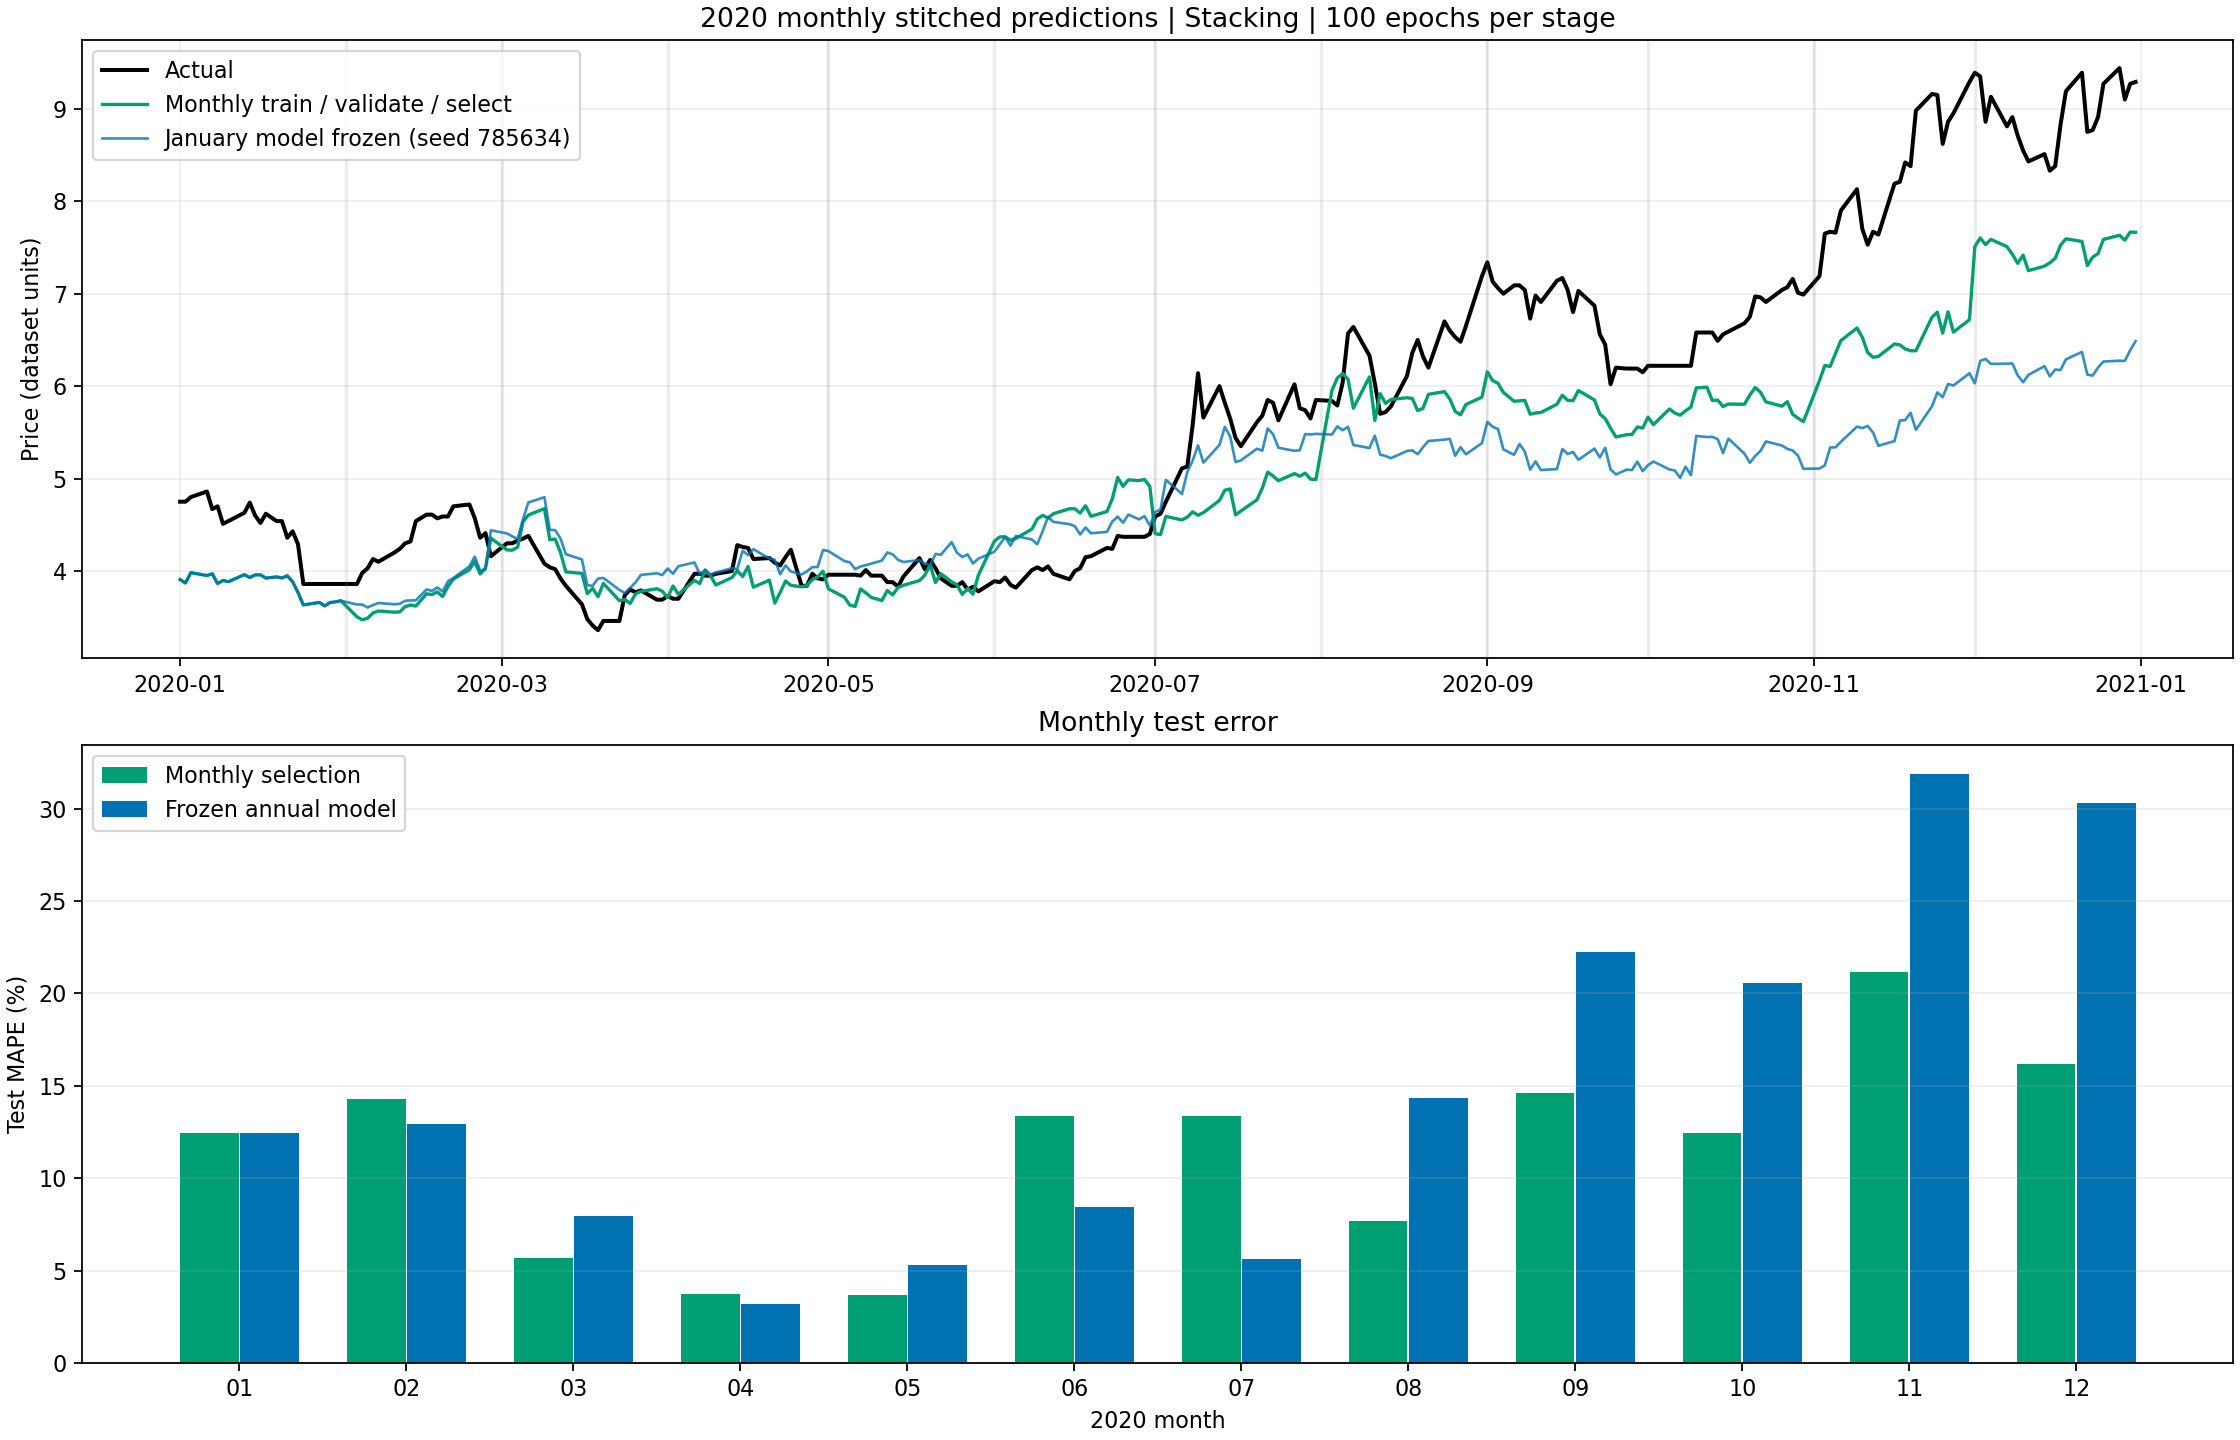

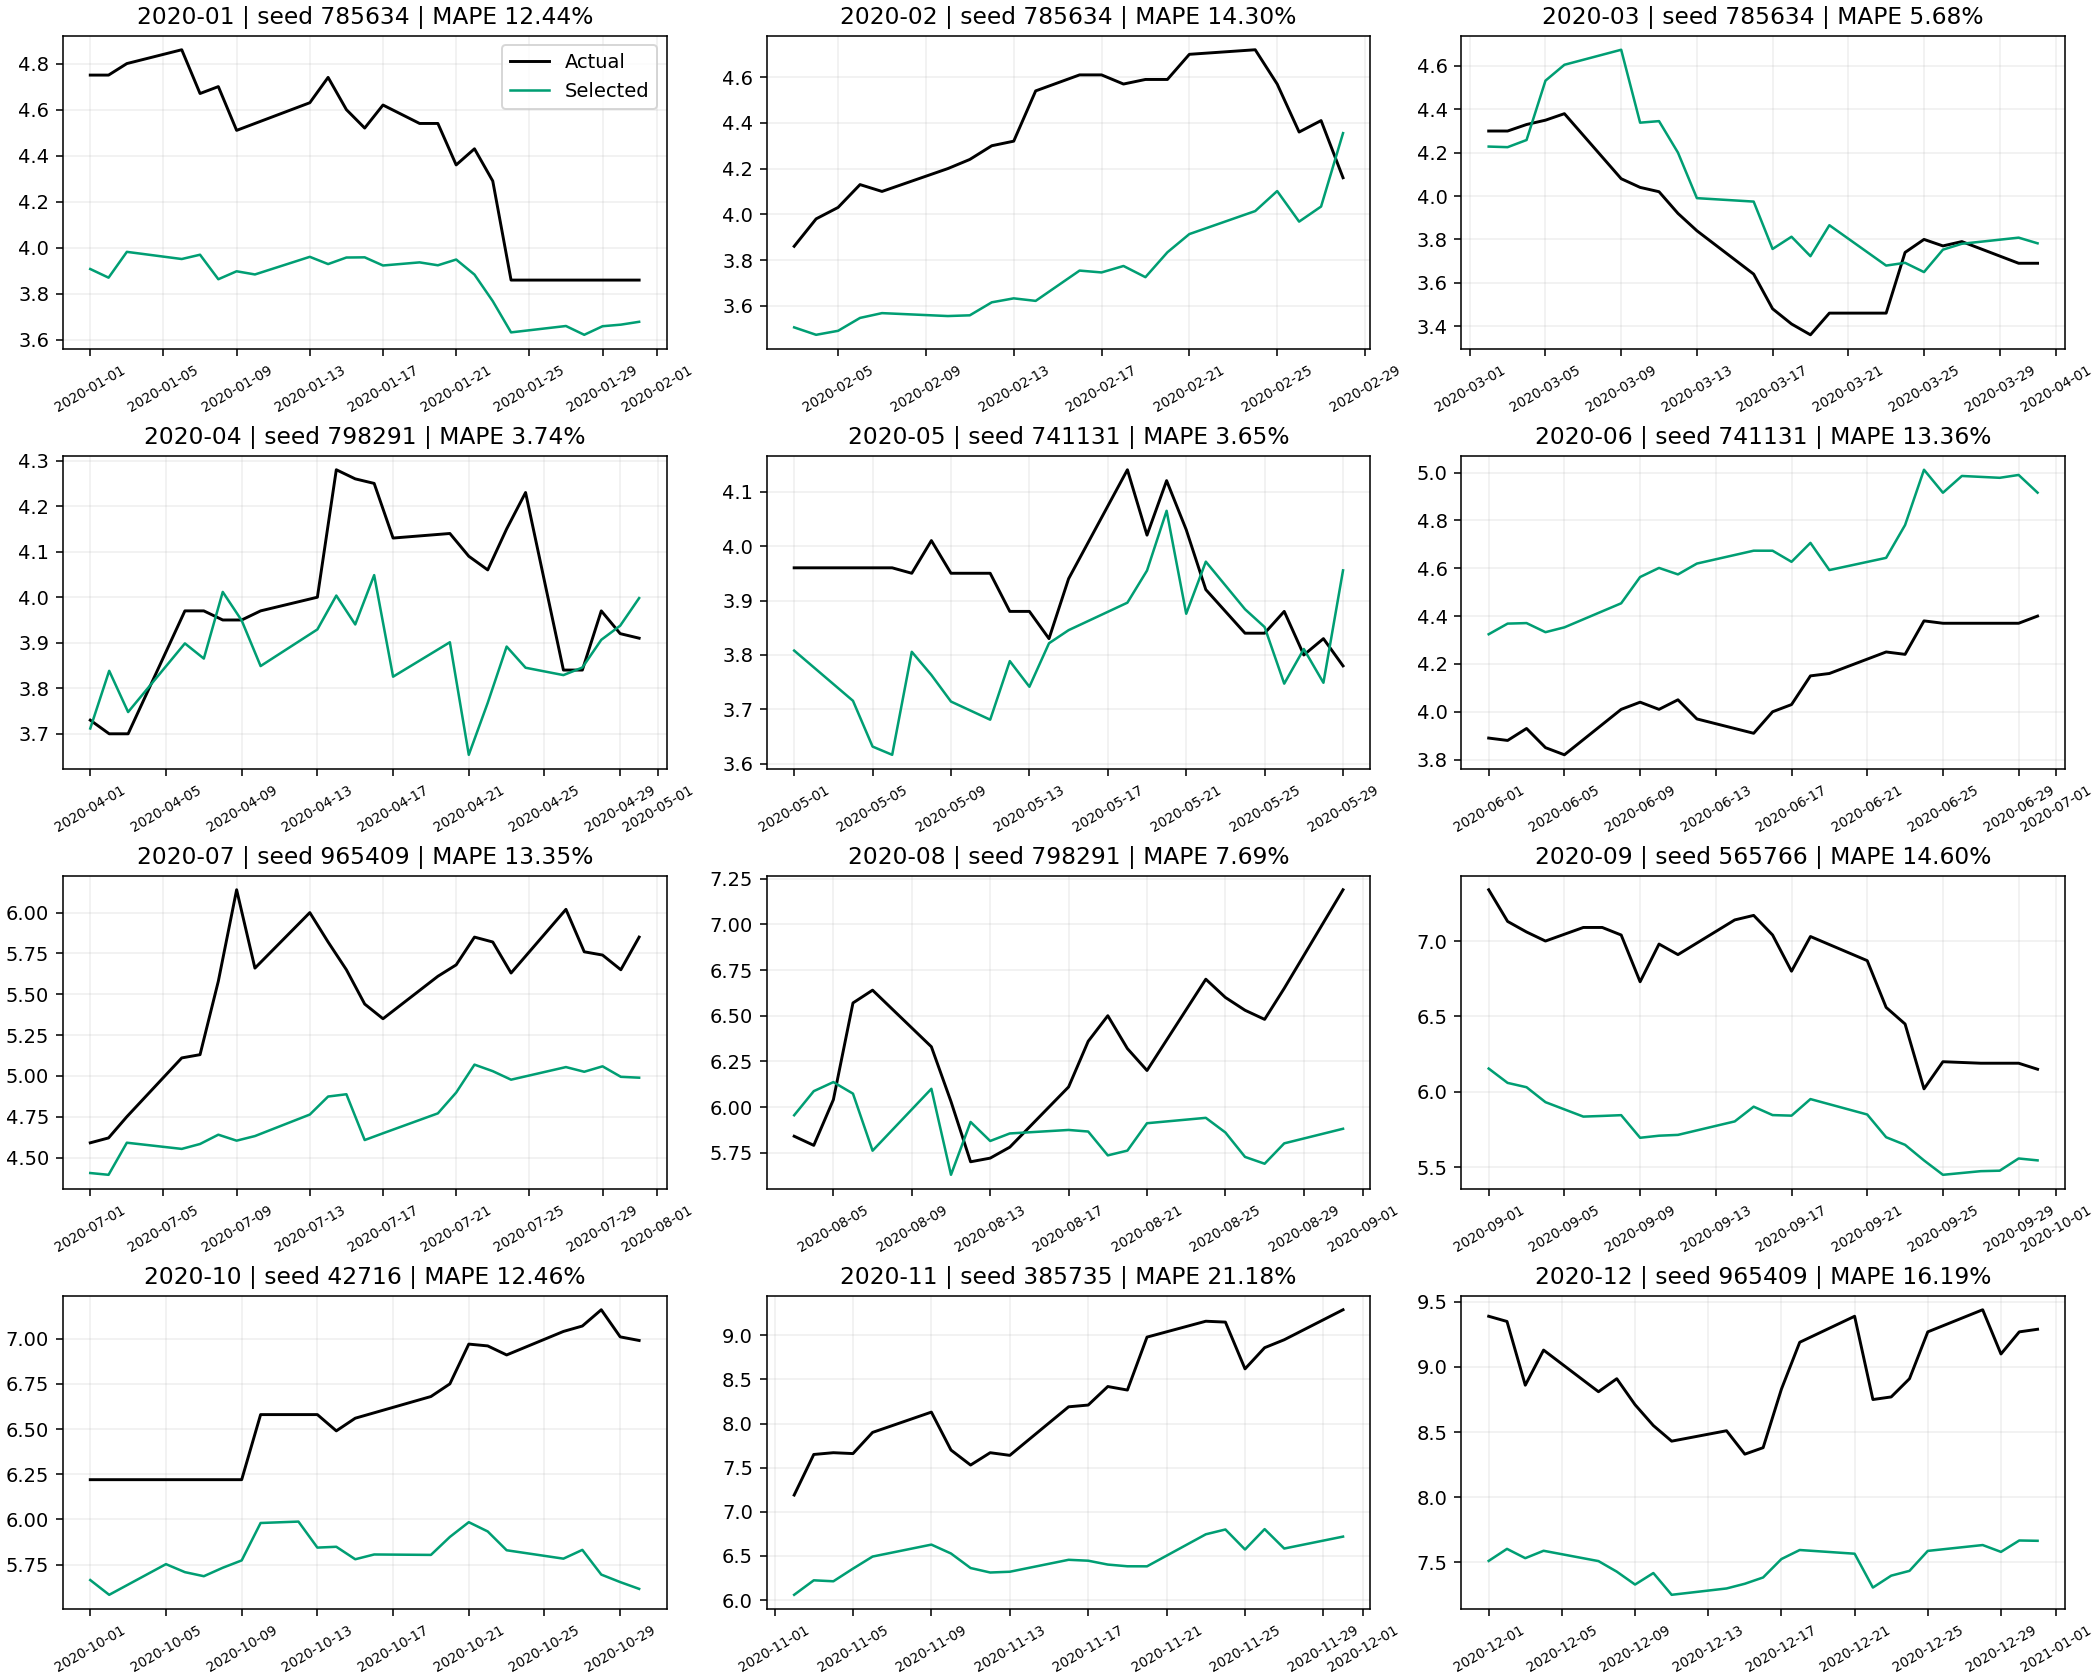

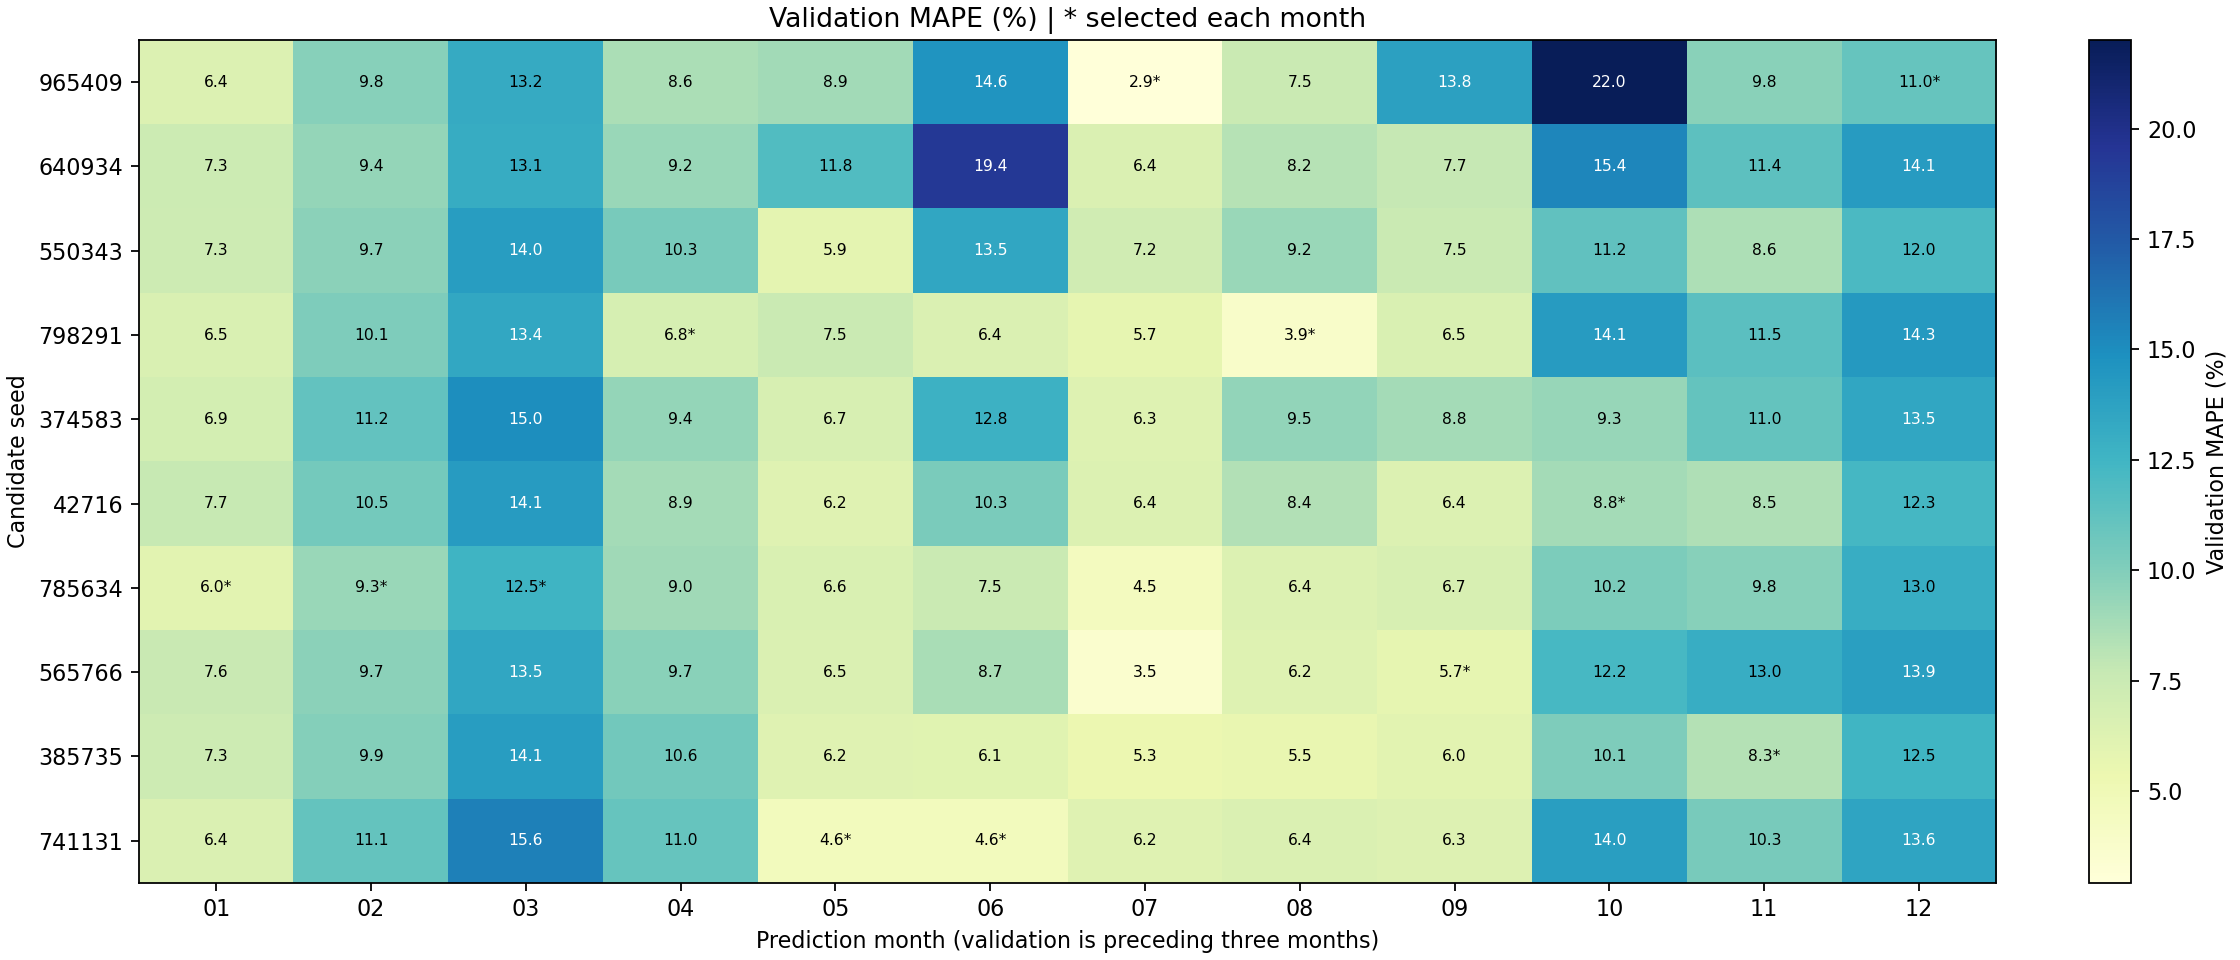

In [3]:
fig,axes=plt.subplots(2,1,figsize=(14,9),constrained_layout=True)
axes[0].plot(stitched.Date,stitched.Actual,color='black',lw=1.8,label='Actual')
axes[0].plot(stitched.Date,stitched.Predicted,color='#009E73',lw=1.5,label='Monthly train / validate / select')
axes[0].plot(stitched.Date,stitched.Frozen_annual_prediction,color='#0072B2',lw=1.2,alpha=.8,label=f'January model frozen (seed {annual_seed})')
for d in pd.date_range('2020-02-01','2020-12-01',freq='MS'):axes[0].axvline(d,color='gray',alpha=.15)
axes[0].set(title='2020 monthly stitched predictions | Stacking | 100 epochs per stage',ylabel='Price (dataset units)');axes[0].legend();axes[0].grid(alpha=.2)
positions=np.arange(12)
axes[1].bar(positions-.18,monthly.Test_MAPE,width=.35,color='#009E73',label='Monthly selection')
axes[1].bar(positions+.18,monthly.Frozen_annual_MAPE,width=.35,color='#0072B2',label='Frozen annual model')
axes[1].set(xticks=positions,xticklabels=[m[-2:] for m in monthly.Month],xlabel='2020 month',ylabel='Test MAPE (%)',title='Monthly test error');axes[1].legend();axes[1].grid(axis='y',alpha=.2)
fig.savefig(OUT/'stitched_comparison.png',dpi=160);plt.close(fig);display(Image(filename=str(OUT/'stitched_comparison.png')))
fig,axes=plt.subplots(4,3,figsize=(15,12),constrained_layout=True)
for ax,(month,g) in zip(axes.flat,stitched.groupby('Month')):
    ax.plot(g.Date,g.Actual,color='black',lw=1.5,label='Actual');ax.plot(g.Date,g.Predicted,color='#009E73',lw=1.3,label='Selected')
    r=monthly[monthly.Month==month].iloc[0]
    ax.set(title=f'{month} | seed {int(r.Selected_seed)} | MAPE {r.Test_MAPE:.2f}%');ax.grid(alpha=.2);ax.tick_params(axis='x',rotation=30,labelsize=7)
axes[0,0].legend();fig.savefig(OUT/'monthly_panels.png',dpi=140);plt.close(fig);display(Image(filename=str(OUT/'monthly_panels.png')))
rankmap=validation.pivot(index='Seed',columns='Month',values='MAPE').reindex(SEEDS)
fig,ax=plt.subplots(figsize=(14,6),constrained_layout=True)
im=ax.imshow(rankmap.to_numpy(),aspect='auto',cmap='YlGnBu')
ax.set(xticks=np.arange(12),xticklabels=[m[-2:] for m in rankmap.columns],yticks=np.arange(10),yticklabels=SEEDS,xlabel='Prediction month (validation is preceding three months)',ylabel='Candidate seed',title='Validation MAPE (%) | * selected each month')
for j,m in enumerate(rankmap.columns):
    chosen=int(selection.loc[selection.Month==m,'Selected_seed'].iloc[0])
    for i,s in enumerate(SEEDS):ax.text(j,i,f'{rankmap.loc[s,m]:.1f}'+('*' if s==chosen else ''),ha='center',va='center',fontsize=7,color='white' if rankmap.loc[s,m]>rankmap.to_numpy().max()*.6 else 'black')
fig.colorbar(im,ax=ax,label='Validation MAPE (%)');fig.savefig(OUT/'validation_heatmap.png',dpi=160);plt.close(fig);display(Image(filename=str(OUT/'validation_heatmap.png')))


## 逐月回测结论

| 月份 | 选中种子 | 前三月验证MAPE | 当月测试MAPE | 年初冻结模型MAPE |
|---|---:|---:|---:|---:|
|2020-01|785634|6.026%|12.442%|12.442%|
|2020-02|785634|9.254%|14.295%|12.933%|
|2020-03|785634|12.547%|5.680%|7.968%|
|2020-04|798291|6.791%|3.745%|3.195%|
|2020-05|741131|4.583%|3.650%|5.318%|
|2020-06|741131|4.616%|13.363%|8.446%|
|2020-07|965409|2.915%|13.347%|5.645%|
|2020-08|798291|3.853%|7.689%|14.355%|
|2020-09|565766|5.680%|14.598%|22.219%|
|2020-10|42716|8.844%|12.456%|20.554%|
|2020-11|385735|8.294%|21.183%|31.879%|
|2020-12|965409|10.996%|16.195%|30.328%|

| 方案 | 全年逐记录MAPE | 12个月等权MAPE | 全年原尺度MSE |
|---|---:|---:|---:|
|逐月训练、前三个月验证选种子|11.5270%|11.5536%|0.7955|
|1月选中模型全年冻结|14.5383%|14.6069%|1.7473|

逐月方案全年逐记录MAPE改善**3.0113个百分点**。1月两方案模型相同；3、5、8—12月改善，2、4、6、7月恶化，尤其6、7月分别比冻结方案高4.92、7.70个百分点。改进主要体现在8—12月，但11月仍有21.18%的测试MAPE，说明方法没有解决所有跨期误差。

本次结果支持“逐月更新整个训练与验证选择流程，比年初选择一次后全年固定更适应这一年”，不能单独证明选种子有效：训练数据每月扩展、验证窗口更新、模型选择变化同时发生。也不能据此认定3个月窗口优于6个月，6个月尚未运行。

10个候选随机种子已在结果出现前抽取、排除旧种子并固定到代码及配置；没有事后重抽种子。每月的selection.json先于当月评价写入；检查训练<验证<测试且三个区间无重叠；全年拼接覆盖原数据2020年全部271条记录、无重复无缺失；1月冻结对照与滚动方案预测一致（浮点容差1e-6）。

每个预测月前有3个月专用于验证且不参与本月训练。例如12月训练截至8月底，验证9—11月。选中后不重训是本次固定方案，意味着最新三个月用于选模型而非更新权重。

**仍需保留时间可用性限制**：模型使用测试日同日的宏观/金铜输入，这不是在月初提前生成整个月预测，而是冻结当月模型后用当日输入作回测。2020年也已用于此前实验，所以本次仍是开发期历史检验。

结果位于 `results/mlp_monthly_validation_12`，包括全年拼接图、12个月小图、验证热力图、逐月边界、候选验证排名、固定选择记录、各候选测试结果、240个阶段权重和训练历史。


---

目前没有把验证集也纳入训练,可能损失了一点信息,我们在进行一次比对.

---

# 固定上次逐月种子，纳入验证数据后重训对比

本节不重新选择种子：直接读取上一实验每月selection.csv中的种子。每个测试月M，把原训练与前三个月验证数据合并为M月之前的全部可用数据，重新拟合标准化器，并用既定种子从头初始化、训练两个阶段各100轮。不是在旧权重上继续加训100轮。

保留原模型结构、特征定义、样本起点、训练超参数、同日目标与测试日期。第二阶段仍用第一阶段样本内预测，不用折外预测。每月测试数据绝不进入重训或标准化。

对比：A上次选好种子直接预测、不重训；B同样种子纳入验证数据后从头重训。只重训每月选中的一个候选，共12个堆叠模型，不重跑10候选验证选择。复用原选择记录，不根据本次测试结果更换种子。

该对比同时反映新增训练数据及其引起的标准化/优化路径变化。最新三个月用于学习是否有益，由相同日期的样本外误差检验。仍是使用同日输入的历史回测，不是月初提前预测全部月内输入未知的股价。


In [1]:
from pathlib import Path
import os,json,hashlib,random
import numpy as np
import pandas as pd
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display,Image
ROOT=next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'src/pickle/Dataset.pkl').exists()),Path('/Users/admin/数据分析/ZiJin-Mining/ZiJin-Mining-stock-prediction-'))
OUT=Path(os.environ.get('MLP12_REFIT_OUT',str(ROOT/'results/mlp_monthly_refit_12')));OUT.mkdir(parents=True,exist_ok=True)
SEEDS=[965409, 640934, 550343, 798291, 374583, 42716, 785634, 565766, 385735, 741131]
EXCLUDED_SEEDS=[0, 1, 7, 21, 42, 100, 123, 999, 2024, 2025]
EPOCHS=100;LR=0.01;VALIDATION_MONTHS=3
torch.set_num_threads(1);torch.use_deterministic_algorithms(True)
assert len(set(SEEDS))==10 and not set(SEEDS)&set(EXCLUDED_SEEDS)
dataset=ROOT/'src/pickle/Dataset.pkl';d=pd.read_pickle(dataset)
raw=d['X'].copy();target=d['Y'].copy();assert raw.index.equals(target.index)
assert raw.index.is_unique and raw.index.is_monotonic_increasing
raw=raw.loc[raw.index<'2021-01-01'];BASE=list(raw.columns);assert len(BASE)==7
y=pd.Series(np.asarray(target).reshape(-1),index=target.index,name='Actual').loc[raw.index]
x=raw.copy();RETURNS=[]
for metal,col in [('gold','Gold Futures Price'),('copper','Copper Futures Price')]:
    name=f'{metal}_daily';x[name]=raw[col]/raw[col].shift(1)-1;RETURNS.append(name)
    for k in [5,20]:
        name=f'{metal}_vs_ma{k}';x[name]=raw[col]/raw[col].rolling(k,min_periods=k).mean()-1;RETURNS.append(name)
valid=np.isfinite(x.to_numpy()).all(axis=1)&np.isfinite(y.to_numpy())
x=x.loc[valid];y=y.loc[x.index];assert (y>0).all()
whole=x.index[x.index.year==2020];assert len(whole)==271
config=dict(seeds=SEEDS,excluded_prior_seeds=EXCLUDED_SEEDS,epochs_per_stage=EPOCHS,validation_months=VALIDATION_MONTHS,hidden=[16,32],activation='ReLU',optimizer='Adam',lr=LR,batch='full',base_features=BASE,stage2_features=['base_prediction']+RETURNS,stage2_training='in-sample predictions; base frozen',refit_after_selection=False,target='same-date original price',selection='minimum preceding-three-calendar-month MAPE; ties by candidate order',test_year=2020,dataset_sha256=hashlib.sha256(dataset.read_bytes()).hexdigest(),torch_version=str(torch.__version__))
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
x.join(y).to_csv(OUT/'features_and_target.csv',index_label='Date')
print('Frozen candidate seeds:',SEEDS)

PRIOR=OUT.parent/'mlp_monthly_validation_12'
if not (PRIOR/'selection.csv').exists():PRIOR=ROOT/'results/mlp_monthly_validation_12'
prior_config=json.loads((PRIOR/'config.json').read_text())
assert prior_config['dataset_sha256']==config['dataset_sha256'] and prior_config['seeds']==SEEDS
selection=pd.read_csv(PRIOR/'selection.csv')
original=pd.read_csv(PRIOR/'stitched_predictions.csv',parse_dates=['Date'])
assert len(selection)==12 and selection.Month.is_unique and len(original)==len(whole)
assert pd.DatetimeIndex(original.Date).equals(whole)
assert np.allclose(original.Actual,y.loc[whole])
config.update(refit_after_selection=True,seed_selection='reuse previous monthly selection.csv without reranking',refit='fresh initialization with selected seed; 100 epochs per stage',selection_sha256=hashlib.sha256((PRIOR/'selection.csv').read_bytes()).hexdigest())
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
selection.to_csv(OUT/'reused_selection.csv',index=False)
display(selection[['Month','Selected_seed','Validation_MAPE']])


,Month,Selected_seed,Validation_MAPE
0,2020-01,785634,6.025555
1,2020-02,785634,9.254464
2,2020-03,785634,12.546828
3,2020-04,798291,6.791479
4,2020-05,741131,4.583056
5,2020-06,741131,4.615878
6,2020-07,965409,2.915300
7,2020-08,798291,3.852990
8,2020-09,565766,5.680123
9,2020-10,42716,8.844333


Frozen candidate seeds: [965409, 640934, 550343, 798291, 374583, 42716, 785634, 565766, 385735, 741131]


In [2]:
history=[]
def fit_stage(X,train_idx,seed,stage,month):
    random.seed(seed);np.random.seed(seed);torch.manual_seed(seed)
    sx=StandardScaler().fit(X.loc[train_idx]);sy=StandardScaler().fit(y.loc[train_idx].to_numpy().reshape(-1,1))
    xt=torch.tensor(sx.transform(X.loc[train_idx]),dtype=torch.float32);yt=torch.tensor(sy.transform(y.loc[train_idx].to_numpy().reshape(-1,1)),dtype=torch.float32)
    model=nn.Sequential(nn.Linear(X.shape[1],16),nn.ReLU(),nn.Linear(16,32),nn.ReLU(),nn.Linear(32,1))
    opt=torch.optim.Adam(model.parameters(),lr=LR)
    for epoch in range(1,EPOCHS+1):
        model.train();opt.zero_grad();loss=((model(xt)-yt)**2).mean();assert torch.isfinite(loss)
        loss.backward();opt.step();model.eval()
        with torch.no_grad():z=model(xt).numpy()
        p=sy.inverse_transform(z).ravel();mse=float(np.mean((p-y.loc[train_idx].to_numpy())**2))
        history.append(dict(Month=month,Seed=seed,Stage=stage,Epoch=epoch,Train_MSE=mse,Train_MSE_standardized=mse/float(sy.scale_[0]**2)))
    torch.save(dict(state_dict=model.state_dict(),features=list(X.columns),seed=seed,epochs=EPOCHS,train_start=str(train_idx.min()),train_end=str(train_idx.max()),sx_mean=sx.mean_.tolist(),sx_scale=sx.scale_.tolist(),sy_mean=sy.mean_.tolist(),sy_scale=sy.scale_.tolist()),OUT/f'{month}_{stage}_seed{seed}.pt')
    return model,sx,sy

def predict(bundle,X):
    model,sx,sy=bundle;model.eval()
    with torch.no_grad():z=model(torch.tensor(sx.transform(X),dtype=torch.float32)).numpy()
    p=sy.inverse_transform(z).ravel();assert np.isfinite(p).all();return pd.Series(p,index=X.index)

def score(pred,idx):
    err=pred.loc[idx].to_numpy()-y.loc[idx].to_numpy()
    return dict(N=len(idx),MAPE=float(100*np.mean(np.abs(err)/np.abs(y.loc[idx].to_numpy()))),MSE=float(np.mean(err**2)))

def stack_predict(base,stack,X):
    bp=predict(base,X[BASE]);meta=X[RETURNS].copy();meta.insert(0,'base_prediction',bp)
    return predict(stack,meta)

frames=[];splits=[];train_metrics=[]
for row in selection.itertuples(index=False):
    month=row.Month;seed=int(row.Selected_seed);start=pd.Timestamp(month+'-01');end=start+pd.DateOffset(months=1)
    tr=x.index[x.index<start];te=x.index[(x.index>=start)&(x.index<end)]
    assert tr.max()<te.min() and str(te.min().date())==row.Test_start and str(te.max().date())==row.Test_end
    assert tr.max()<=pd.Timestamp(row.Validation_end) and tr.min()==x.index.min()
    known=x.loc[tr]
    base=fit_stage(known[BASE],tr,seed,'Base',month)
    bp=predict(base,known[BASE]);meta=known[RETURNS].copy();meta.insert(0,'base_prediction',bp)
    stack=fit_stage(meta,tr,seed,'Stacking',month)
    pred=stack_predict(base,stack,x.loc[te]);train_pred=predict(stack,meta)
    train_metrics.append(dict(Month=month,Seed=seed,**score(train_pred,tr)))
    frames.append(pd.DataFrame(dict(Date=te,Month=month,Seed=seed,Actual=y.loc[te].to_numpy(),Refit_prediction=pred.to_numpy())))
    for split,idx in [('Refit_train',tr),('Test',te)]:splits.append(dict(Month=month,Split=split,N=len(idx),Start=str(idx.min().date()),End=str(idx.max().date())))
    print(f'{month}: reused seed {seed}; refit {len(tr)} records; test {len(te)} records',flush=True)
refit=pd.concat(frames,ignore_index=True).sort_values('Date')
assert refit.Date.is_unique and pd.DatetimeIndex(refit.Date).equals(whole) and len(history)==2400
comparison=refit.merge(original[['Date','Month','Seed','Actual','Predicted']].rename(columns={'Predicted':'No_refit_prediction'}),on=['Date','Month','Seed'],suffixes=('','_old'),validate='one_to_one')
assert len(comparison)==len(whole) and np.allclose(comparison.Actual,comparison.Actual_old)
comparison=comparison.drop(columns='Actual_old')
comparison['Refit_APE']=100*np.abs(comparison.Refit_prediction-comparison.Actual)/comparison.Actual.abs()
comparison['No_refit_APE']=100*np.abs(comparison.No_refit_prediction-comparison.Actual)/comparison.Actual.abs()
monthly=comparison.groupby('Month').agg(Selected_seed=('Seed','first'),N=('Date','size'),No_refit_MAPE=('No_refit_APE','mean'),Refit_MAPE=('Refit_APE','mean'))
monthly['Refit_minus_no_refit_pp']=monthly.Refit_MAPE-monthly.No_refit_MAPE
monthly['Improved']=monthly.Refit_minus_no_refit_pp<0
summary=pd.DataFrame([dict(Method=label,Annual_daily_MAPE=comparison[ape].mean(),Monthly_equal_MAPE=monthly[col].mean(),Annual_MSE=np.mean((comparison[predcol]-comparison.Actual)**2)) for label,ape,col,predcol in [('No refit (previous selected models)','No_refit_APE','No_refit_MAPE','No_refit_prediction'),('Refit training plus validation','Refit_APE','Refit_MAPE','Refit_prediction')]])
assert np.isclose(summary.iloc[1].Annual_daily_MAPE,np.average(monthly.Refit_MAPE,weights=monthly.N))
old_monthly=pd.read_csv(PRIOR/'monthly_results.csv').set_index('Month')
assert np.allclose(monthly.No_refit_MAPE,old_monthly.Test_MAPE,atol=1e-5)
comparison.to_csv(OUT/'stitched_comparison.csv',index=False);monthly.to_csv(OUT/'monthly_comparison.csv');summary.to_csv(OUT/'summary.csv',index=False)
pd.DataFrame(history).to_csv(OUT/'training_history.csv',index=False);pd.DataFrame(train_metrics).to_csv(OUT/'refit_train_metrics.csv',index=False);pd.DataFrame(splits).to_csv(OUT/'splits.csv',index=False)
print('Monthly paired results (negative difference is improvement):');display(monthly.round(4))
print('Annual summary:');display(summary.round(4))
print(f'Refit improved {int(monthly.Improved.sum())}/12 months')


,Selected_seed,N,No_refit_MAPE,Refit_MAPE,Refit_minus_no_refit_pp,Improved
Month,,,,,,
2020-01,785634,24,12.4420,8.4636,-3.9784,True
2020-02,785634,21,14.2954,6.2803,-8.0151,True
2020-03,785634,22,5.6804,10.8491,5.1687,False
2020-04,798291,23,3.7448,7.3819,3.6371,False
2020-05,741131,23,3.6497,4.2413,0.5916,False
2020-06,741131,23,13.3628,9.2889,-4.0738,True
2020-07,965409,23,13.3470,14.0170,0.6700,False
2020-08,798291,21,7.6893,5.4751,-2.2143,True
2020-09,565766,24,14.5983,11.4930,-3.1053,True


,Method,Annual_daily_MAPE,Monthly_equal_MAPE,Annual_MSE
0,No refit (previous selected models),11.5270,11.5536,0.7955
1,Refit training plus validation,8.1499,8.1528,0.3381


2020-01: reused seed 785634; refit 2035 records; test 24 records
2020-02: reused seed 785634; refit 2059 records; test 21 records
2020-03: reused seed 785634; refit 2080 records; test 22 records
2020-04: reused seed 798291; refit 2102 records; test 23 records
2020-05: reused seed 741131; refit 2125 records; test 23 records
2020-06: reused seed 741131; refit 2148 records; test 23 records
2020-07: reused seed 965409; refit 2171 records; test 23 records
2020-08: reused seed 798291; refit 2194 records; test 21 records
2020-09: reused seed 565766; refit 2215 records; test 24 records
2020-10: reused seed 42716; refit 2239 records; test 23 records
2020-11: reused seed 385735; refit 2262 records; test 21 records
2020-12: reused seed 965409; refit 2283 records; test 23 records
Monthly paired results (negative difference is improvement):
Annual summary:
Refit improved 8/12 months


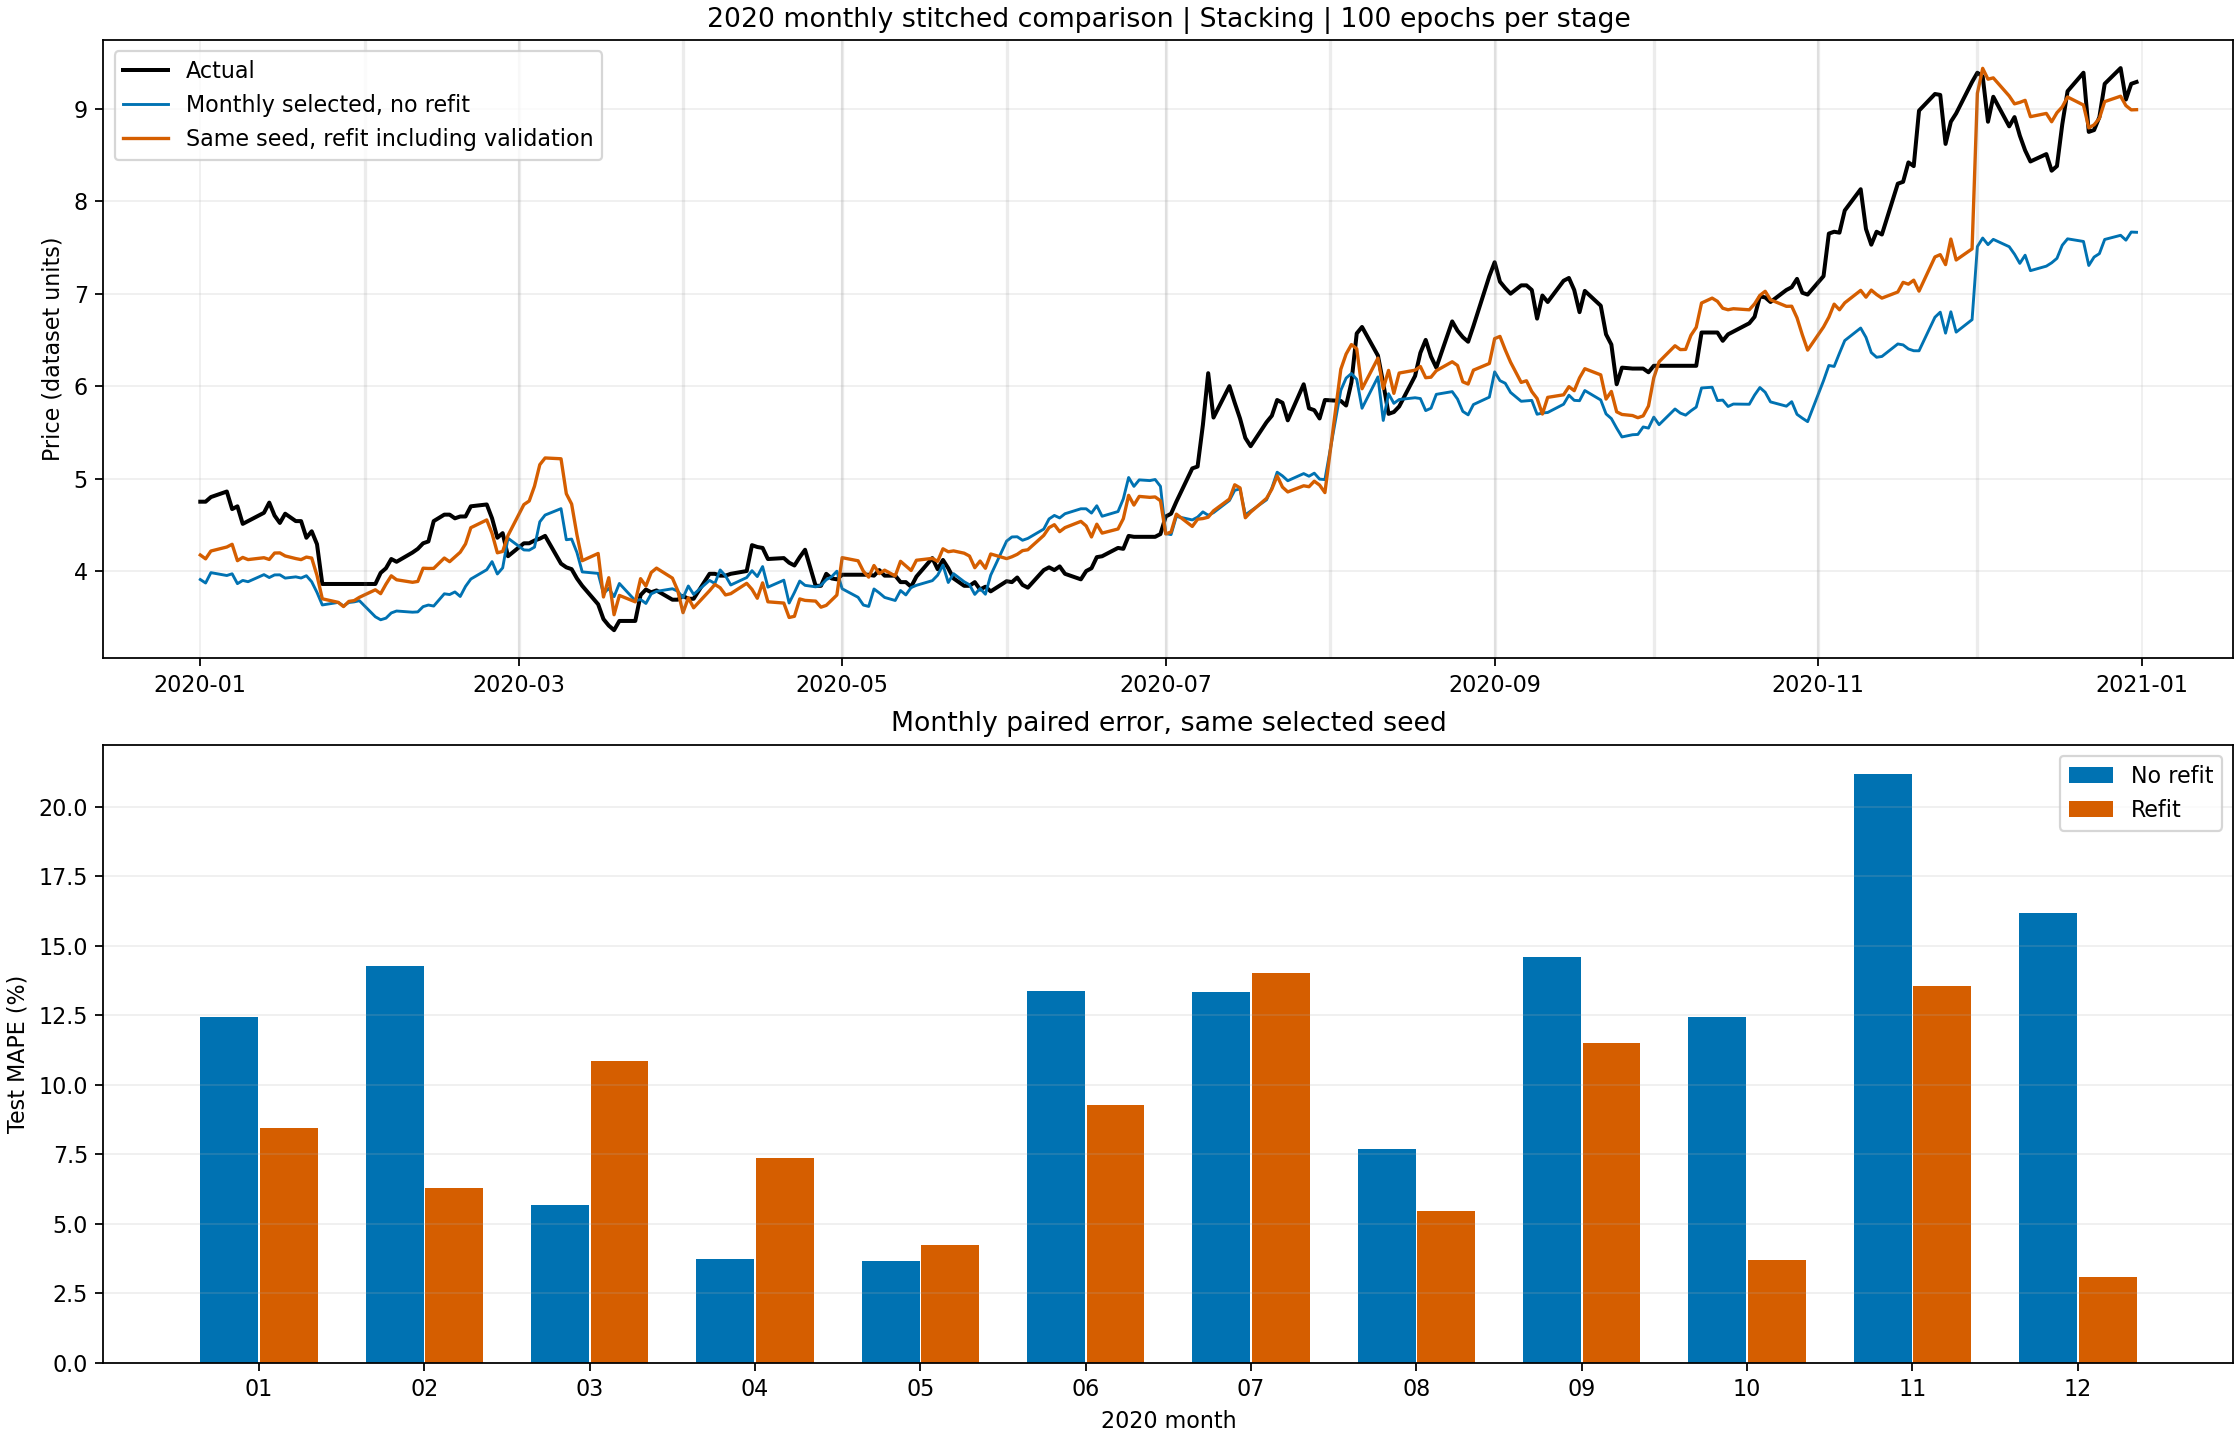

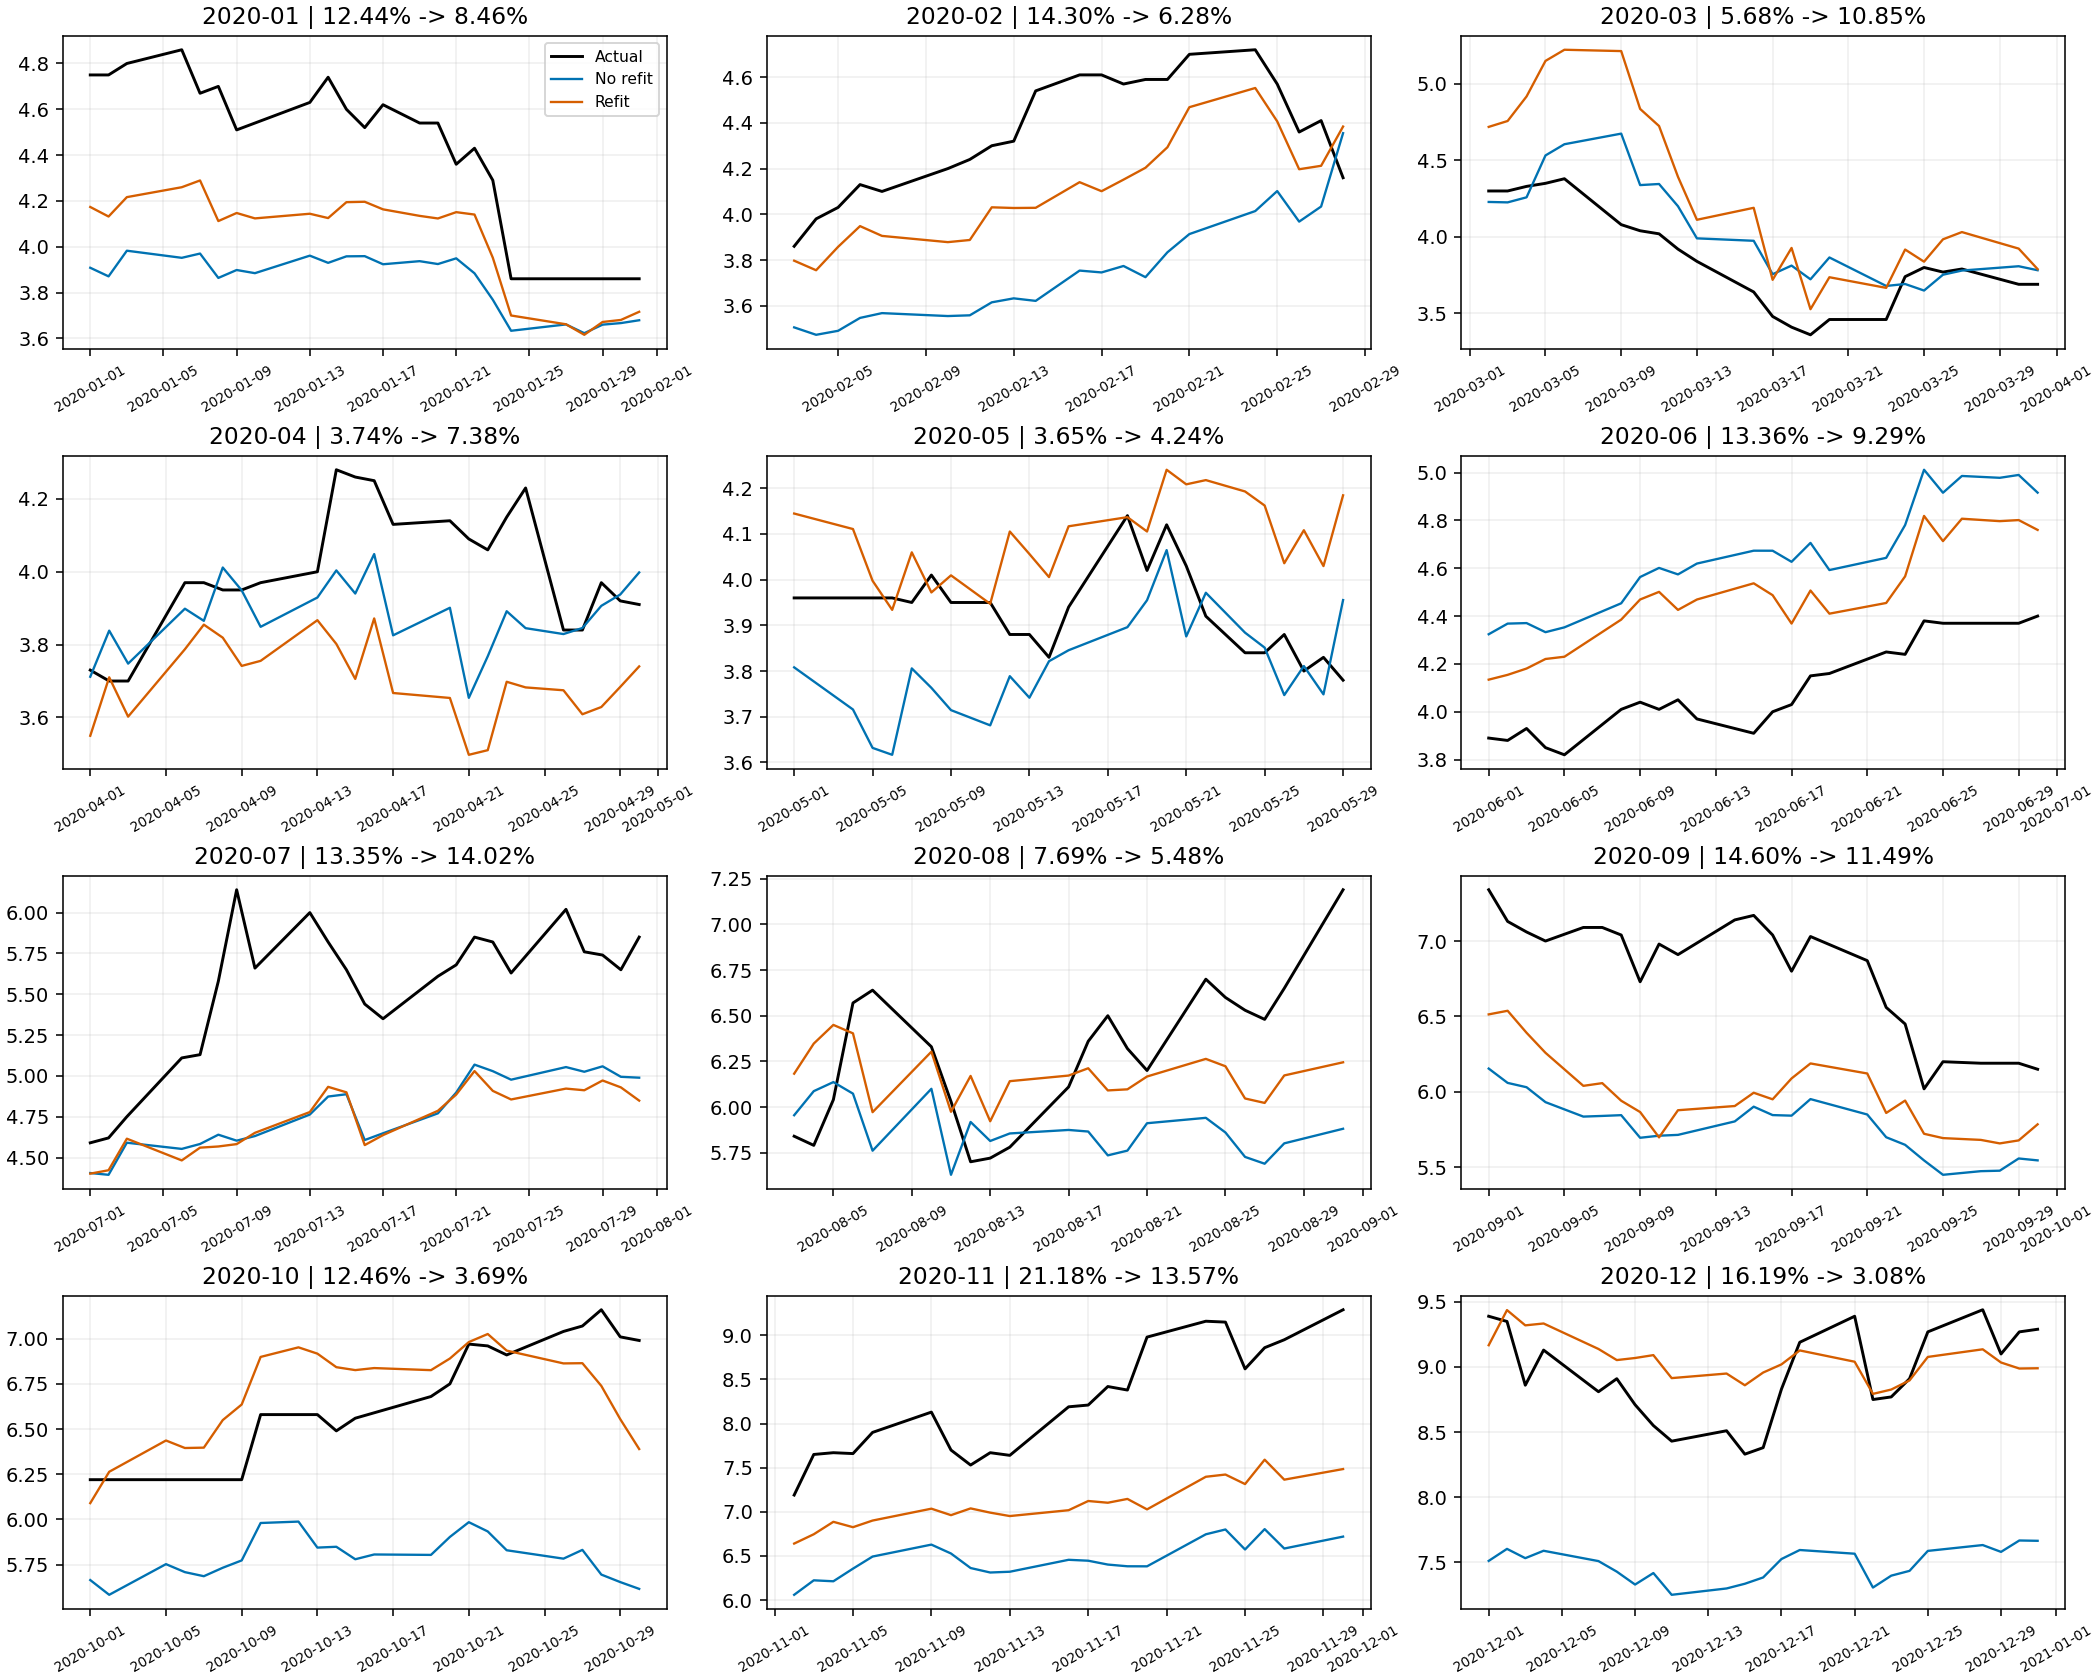

In [3]:
fig,axes=plt.subplots(2,1,figsize=(14,9),constrained_layout=True)
axes[0].plot(comparison.Date,comparison.Actual,color='black',lw=1.8,label='Actual')
axes[0].plot(comparison.Date,comparison.No_refit_prediction,color='#0072B2',lw=1.3,label='Monthly selected, no refit')
axes[0].plot(comparison.Date,comparison.Refit_prediction,color='#D55E00',lw=1.5,label='Same seed, refit including validation')
for d in pd.date_range('2020-02-01','2020-12-01',freq='MS'):axes[0].axvline(d,color='gray',alpha=.15)
axes[0].set(title='2020 monthly stitched comparison | Stacking | 100 epochs per stage',ylabel='Price (dataset units)');axes[0].legend();axes[0].grid(alpha=.2)
pos=np.arange(12)
axes[1].bar(pos-.18,monthly.No_refit_MAPE,width=.35,color='#0072B2',label='No refit')
axes[1].bar(pos+.18,monthly.Refit_MAPE,width=.35,color='#D55E00',label='Refit')
axes[1].set(xticks=pos,xticklabels=[m[-2:] for m in monthly.index],xlabel='2020 month',ylabel='Test MAPE (%)',title='Monthly paired error, same selected seed');axes[1].legend();axes[1].grid(axis='y',alpha=.2)
fig.savefig(OUT/'refit_comparison.png',dpi=160);plt.close(fig);display(Image(filename=str(OUT/'refit_comparison.png')))
fig,axes=plt.subplots(4,3,figsize=(15,12),constrained_layout=True)
for ax,(month,g) in zip(axes.flat,comparison.groupby('Month')):
    ax.plot(g.Date,g.Actual,color='black',lw=1.5,label='Actual');ax.plot(g.Date,g.No_refit_prediction,color='#0072B2',lw=1.2,label='No refit');ax.plot(g.Date,g.Refit_prediction,color='#D55E00',lw=1.2,label='Refit')
    r=monthly.loc[month]
    ax.set(title=f'{month} | {r.No_refit_MAPE:.2f}% -> {r.Refit_MAPE:.2f}%');ax.grid(alpha=.2);ax.tick_params(axis='x',rotation=30,labelsize=7)
axes[0,0].legend(fontsize=8);fig.savefig(OUT/'monthly_panels.png',dpi=140);plt.close(fig);display(Image(filename=str(OUT/'monthly_panels.png')))


## 纳入验证集重训的结果

| 月份 | 固定种子 | 不重训MAPE | 纳入验证集重训MAPE | 重训−不重训（百分点） |
|---|---:|---:|---:|---:|
|2020-01|785634|12.442%|8.464%|-3.978|
|2020-02|785634|14.295%|6.280%|-8.015|
|2020-03|785634|5.680%|10.849%|+5.169|
|2020-04|798291|3.745%|7.382%|+3.637|
|2020-05|741131|3.650%|4.241%|+0.592|
|2020-06|741131|13.363%|9.289%|-4.074|
|2020-07|965409|13.347%|14.017%|+0.670|
|2020-08|798291|7.689%|5.475%|-2.214|
|2020-09|565766|14.598%|11.493%|-3.105|
|2020-10|42716|12.456%|3.691%|-8.765|
|2020-11|385735|21.183%|13.574%|-7.610|
|2020-12|965409|16.195%|3.079%|-13.116|

| 方案 | 全年逐记录MAPE | 月度等权平均MAPE | 全年原股价尺度MSE |
|---|---:|---:|---:|
|原选中模型直接预测，不重训|11.5270%|11.5536%|0.7955|
|固定种子，加入验证数据后从头重训|8.1499%|8.1528%|0.3381|

全年MAPE降低3.3771个百分点，约相对降低29.3%。12个月中8个月改善；3、4、5、7月变差。改善较大的是12月（−13.12个百分点）、10月（−8.76）、2月（−8.02）、11月（−7.61）。因此，本次历史实验支持利用最近三个月重新训练能够改善总体表现，但并非每个月必然改善。

本次完全复用上一实验每个月的种子，不再进行10候选选择。标准化器和两个阶段的权重均在合并后的训练数据上重新拟合/初始化，各100轮。结果不能解释为旧模型继续训练的收益，也不能单独分离“新增样本”和“标准化、优化路径变化”的贡献。

每月测试集均在重训数据之后；全年271条记录无重复无缺失，与不重训结果按日期/月/种子一一配对。旧结果保持不变，新输出位于 `results/mlp_monthly_refit_12`，包括重训权重、训练历史、拼接预测、月度对照图及汇总。

仍为使用同日金铜等输入的样本外历史回测；2020年已经被反复研究，需在未参与开发的时期验证能否推广。


但是如果是一个月更新一次权重,会让跳变非常突兀,且只有在月末才更新.

应该设计一个更新条件.